In [1]:
import os

os.listdir('/content/drive/MyDrive')

['Science (1).png',
 'Science.png',
 'Untitled folder',
 'ChestXRay Data.zip',
 'Colab Notebooks']

In [2]:
!unzip -q "/content/drive/MyDrive/ChestXRay Data.zip" -d /content/dataset

In [3]:
import os

os.listdir("/content/dataset")

['train.csv', 'train', 'valid.csv', 'valid']

In [4]:
import pandas as pd

train_df = pd.read_csv("/content/dataset/train.csv")
valid_df = pd.read_csv("/content/dataset/valid.csv")

print("Training set:", train_df.shape)
print("Validation set:", valid_df.shape)

train_df.head()

Training set: (223414, 19)
Validation set: (234, 19)


,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [5]:
train_df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 223414 entries, 0 to 223413
Data columns (total 19 columns):
 #   Column                      Non-Null Count   Dtype  
---  ------                      --------------   -----  
 0   Path                        223414 non-null  object 
 1   Sex                         223414 non-null  object 
 2   Age                         223414 non-null  int64  
 3   Frontal/Lateral             223414 non-null  object 
 4   AP/PA                       191027 non-null  object 
 5   No Finding                  22381 non-null   float64
 6   Enlarged Cardiomediastinum  44839 non-null   float64
 7   Cardiomegaly                46203 non-null   float64
 8   Lung Opacity                117778 non-null  float64
 9   Lung Lesion                 11944 non-null   float64
 10  Edema                       85956 non-null   float64
 11  Consolidation               70622 non-null   float64
 12  Pneumonia                   27608 non-null   float64
 13  Atelectasis   

In [6]:
train_df.head()

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN


In [7]:
train_df.isnull().sum().sort_values(ascending=False)

,0
Pleural Other,216922
Lung Lesion,211470
Fracture,211220
No Finding,201033
Pneumonia,195806
Enlarged Cardiomediastinum,178575
Cardiomegaly,177211
Atelectasis,154971
Consolidation,152792
Pneumothorax,144480


In [8]:
print(train_df.columns.tolist())

['Path', 'Sex', 'Age', 'Frontal/Lateral', 'AP/PA', 'No Finding', 'Enlarged Cardiomediastinum', 'Cardiomegaly', 'Lung Opacity', 'Lung Lesion', 'Edema', 'Consolidation', 'Pneumonia', 'Atelectasis', 'Pneumothorax', 'Pleural Effusion', 'Pleural Other', 'Fracture', 'Support Devices']


In [9]:
disease_columns = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion",
    "Pneumothorax",
    "Lung Opacity",
    "Pneumonia",
    "No Finding"
]

for col in disease_columns:
    print(f"\n{col}")
    print(train_df[col].value_counts(dropna=False))


Atelectasis
Atelectasis
 NaN    154971
-1.0     33739
 1.0     33376
 0.0      1328
Name: count, dtype: int64

Cardiomegaly
Cardiomegaly
 NaN    177211
 1.0     27000
 0.0     11116
-1.0      8087
Name: count, dtype: int64

Consolidation
Consolidation
 NaN    152792
 0.0     28097
-1.0     27742
 1.0     14783
Name: count, dtype: int64

Edema
Edema
 NaN    137458
 1.0     52246
 0.0     20726
-1.0     12984
Name: count, dtype: int64

Pleural Effusion
Pleural Effusion
 NaN    90203
 1.0    86187
 0.0    35396
-1.0    11628
Name: count, dtype: int64

Pneumothorax
Pneumothorax
 NaN    144480
 0.0     56341
 1.0     19448
-1.0      3145
Name: count, dtype: int64

Lung Opacity
Lung Opacity
 NaN    105636
 1.0    105581
 0.0      6599
-1.0      5598
Name: count, dtype: int64

Pneumonia
Pneumonia
 NaN    195806
-1.0     18770
 1.0      6039
 0.0      2799
Name: count, dtype: int64

No Finding
No Finding
NaN    201033
1.0     22381
Name: count, dtype: int64


In [10]:
train_df.head(10)

,Path,Sex,Age,Frontal/Lateral,AP/PA,No Finding,Enlarged Cardiomediastinum,Cardiomegaly,Lung Opacity,Lung Lesion,Edema,Consolidation,Pneumonia,Atelectasis,Pneumothorax,Pleural Effusion,Pleural Other,Fracture,Support Devices
0,CheXpert-v1.0-small/train/patient00001/study1/...,Female,68,Frontal,AP,1.0,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,1.0
1,CheXpert-v1.0-small/train/patient00002/study2/...,Female,87,Frontal,AP,NaN,NaN,-1.0,1.0,NaN,-1.0,-1.0,NaN,-1.0,NaN,-1.0,NaN,1.0,NaN
2,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Frontal,AP,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
3,CheXpert-v1.0-small/train/patient00002/study1/...,Female,83,Lateral,NaN,NaN,NaN,NaN,1.0,NaN,NaN,-1.0,NaN,NaN,NaN,NaN,NaN,1.0,NaN
4,CheXpert-v1.0-small/train/patient00003/study1/...,Male,41,Frontal,AP,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,NaN
5,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Frontal,PA,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
6,CheXpert-v1.0-small/train/patient00004/study1/...,Female,20,Lateral,NaN,1.0,0.0,NaN,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN
7,CheXpert-v1.0-small/train/patient00005/study1/...,Male,33,Frontal,PA,1.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,1.0
8,CheXpert-v1.0-small/train/patient00005/study1/...,Male,33,Lateral,NaN,1.0,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,NaN,0.0,NaN,NaN,1.0
9,CheXpert-v1.0-small/train/patient00005/study2/...,Male,33,Frontal,AP,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,NaN,1.0,NaN,NaN,NaN,NaN


In [11]:
train_df["Path"].head(10)

,Path
0,CheXpert-v1.0-small/train/patient00001/study1/...
1,CheXpert-v1.0-small/train/patient00002/study2/...
2,CheXpert-v1.0-small/train/patient00002/study1/...
3,CheXpert-v1.0-small/train/patient00002/study1/...
4,CheXpert-v1.0-small/train/patient00003/study1/...
5,CheXpert-v1.0-small/train/patient00004/study1/...
6,CheXpert-v1.0-small/train/patient00004/study1/...
7,CheXpert-v1.0-small/train/patient00005/study1/...
8,CheXpert-v1.0-small/train/patient00005/study1/...
9,CheXpert-v1.0-small/train/patient00005/study2/...


In [12]:
train_df["No Finding"].value_counts(dropna=False)

,count
No Finding,
NaN,201033
1.0,22381


In [13]:
TARGET_DISEASES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

In [14]:
required_columns = [
    "Path",
    "Sex",
    "Age",
    "Frontal/Lateral",
    "AP/PA"
] + TARGET_DISEASES

train_clean = train_df[required_columns].copy()
valid_clean = valid_df[required_columns].copy()

print(train_clean.head())
print(train_clean.shape)

                                                Path     Sex  Age  \
0  CheXpert-v1.0-small/train/patient00001/study1/...  Female   68   
1  CheXpert-v1.0-small/train/patient00002/study2/...  Female   87   
2  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
3  CheXpert-v1.0-small/train/patient00002/study1/...  Female   83   
4  CheXpert-v1.0-small/train/patient00003/study1/...    Male   41   

  Frontal/Lateral AP/PA  Atelectasis  Cardiomegaly  Consolidation  Edema  \
0         Frontal    AP          NaN           NaN            NaN    NaN   
1         Frontal    AP         -1.0          -1.0           -1.0   -1.0   
2         Frontal    AP          NaN           NaN           -1.0    NaN   
3         Lateral   NaN          NaN           NaN           -1.0    NaN   
4         Frontal    AP          NaN           NaN            NaN    1.0   

   Pleural Effusion  
0               NaN  
1              -1.0  
2               NaN  
3               NaN  
4               Na

In [15]:
for disease in TARGET_DISEASES:
    print(f"\n{disease}")
    print(train_clean[disease].value_counts(dropna=False))


Atelectasis
Atelectasis
 NaN    154971
-1.0     33739
 1.0     33376
 0.0      1328
Name: count, dtype: int64

Cardiomegaly
Cardiomegaly
 NaN    177211
 1.0     27000
 0.0     11116
-1.0      8087
Name: count, dtype: int64

Consolidation
Consolidation
 NaN    152792
 0.0     28097
-1.0     27742
 1.0     14783
Name: count, dtype: int64

Edema
Edema
 NaN    137458
 1.0     52246
 0.0     20726
-1.0     12984
Name: count, dtype: int64

Pleural Effusion
Pleural Effusion
 NaN    90203
 1.0    86187
 0.0    35396
-1.0    11628
Name: count, dtype: int64


In [16]:
TARGET_DISEASES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

train_processed = train_clean.copy()

# Fill missing labels with 0
train_processed[TARGET_DISEASES] = train_processed[TARGET_DISEASES].fillna(0)

# Keep only rows without uncertain labels
mask = ~(train_processed[TARGET_DISEASES] == -1).any(axis=1)
train_processed = train_processed[mask]

print("Remaining samples:", len(train_processed))
print(train_processed[TARGET_DISEASES].apply(pd.Series.value_counts))

Remaining samples: 159329
     Atelectasis  Cardiomegaly  Consolidation   Edema  Pleural Effusion
0.0       132182        139908         148273  118803             95556
1.0        27147         19421          11056   40526             63773


In [17]:
import os

DATASET_ROOT = "/content/dataset"

sample_paths = train_processed["Path"].sample(5, random_state=42)

for path in sample_paths:
    full_path = os.path.join(DATASET_ROOT, path)
    print(full_path, os.path.exists(full_path))

/content/dataset/CheXpert-v1.0-small/train/patient26941/study1/view2_lateral.jpg False
/content/dataset/CheXpert-v1.0-small/train/patient10959/study1/view1_frontal.jpg False
/content/dataset/CheXpert-v1.0-small/train/patient09354/study7/view1_frontal.jpg False
/content/dataset/CheXpert-v1.0-small/train/patient31619/study6/view1_frontal.jpg False
/content/dataset/CheXpert-v1.0-small/train/patient17462/study1/view1_frontal.jpg False


In [18]:
import os

print(os.listdir("/content"))

['.config', 'dataset', 'drive', 'sample_data']


In [19]:
print(os.listdir("/content/dataset"))

['train.csv', 'train', 'valid.csv', 'valid']


In [20]:
print(os.listdir("/content"))

['.config', 'dataset', 'drive', 'sample_data']


In [21]:
import os

print(os.listdir("/content/dataset"))

['train.csv', 'train', 'valid.csv', 'valid']


In [22]:
train_processed["Path"] = train_processed["Path"].str.replace(
    "CheXpert-v1.0-small/",
    "",
    regex=False
)

valid_clean["Path"] = valid_clean["Path"].str.replace(
    "CheXpert-v1.0-small/",
    "",
    regex=False
)

In [23]:
DATASET_ROOT = "/content/dataset"

In [24]:
import os

sample_paths = train_processed["Path"].sample(5, random_state=42)

for path in sample_paths:
    full_path = os.path.join(DATASET_ROOT, path)
    print(full_path)
    print(os.path.exists(full_path))
    print("-" * 50)

/content/dataset/train/patient26941/study1/view2_lateral.jpg
True
--------------------------------------------------
/content/dataset/train/patient10959/study1/view1_frontal.jpg
True
--------------------------------------------------
/content/dataset/train/patient09354/study7/view1_frontal.jpg
True
--------------------------------------------------
/content/dataset/train/patient31619/study6/view1_frontal.jpg
True
--------------------------------------------------
/content/dataset/train/patient17462/study1/view1_frontal.jpg
True
--------------------------------------------------


In [25]:
from torchvision import transforms

IMAGE_SIZE = 224

train_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.RandomHorizontalFlip(p=0.5),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

valid_transform = transforms.Compose([
    transforms.Resize((IMAGE_SIZE, IMAGE_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(
        mean=[0.485, 0.456, 0.406],
        std=[0.229, 0.224, 0.225]
    )
])

In [26]:
from torch.utils.data import Dataset
from PIL import Image
import torch
import os

class CheXpertDataset(Dataset):
    def __init__(self, dataframe, root_dir, transform=None):
        self.dataframe = dataframe.reset_index(drop=True)
        self.root_dir = root_dir
        self.transform = transform

        self.labels = [
            "Atelectasis",
            "Cardiomegaly",
            "Consolidation",
            "Edema",
            "Pleural Effusion"
        ]

    def __len__(self):
        return len(self.dataframe)

    def __getitem__(self, idx):
        row = self.dataframe.iloc[idx]

        image_path = os.path.join(self.root_dir, row["Path"])

        image = Image.open(image_path).convert("RGB")

        if self.transform:
            image = self.transform(image)

        label = torch.tensor(
            row[self.labels].values.astype("float32"),
            dtype=torch.float32
        )

        return image, label

In [27]:
train_dataset = CheXpertDataset(
    dataframe=train_processed,
    root_dir=DATASET_ROOT,
    transform=train_transform
)

valid_dataset = CheXpertDataset(
    dataframe=valid_clean,
    root_dir=DATASET_ROOT,
    transform=valid_transform
)

print("Training Images :", len(train_dataset))
print("Validation Images:", len(valid_dataset))

Training Images : 159329
Validation Images: 234


In [28]:
from torch.utils.data import DataLoader

BATCH_SIZE = 32

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True,
    num_workers=2,
    pin_memory=True
)

valid_loader = DataLoader(
    valid_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False,
    num_workers=2,
    pin_memory=True
)

print("Train batches:", len(train_loader))
print("Validation batches:", len(valid_loader))

Train batches: 4980
Validation batches: 8


In [29]:
images, labels = next(iter(train_loader))

print("Image batch shape :", images.shape)
print("Label batch shape :", labels.shape)

print("\nFirst 5 label vectors:")
print(labels[:5])

Image batch shape : torch.Size([32, 3, 224, 224])
Label batch shape : torch.Size([32, 5])

First 5 label vectors:
tensor([[1., 0., 0., 0., 1.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 0., 0.],
        [0., 0., 0., 0., 1.],
        [0., 0., 0., 1., 0.]])


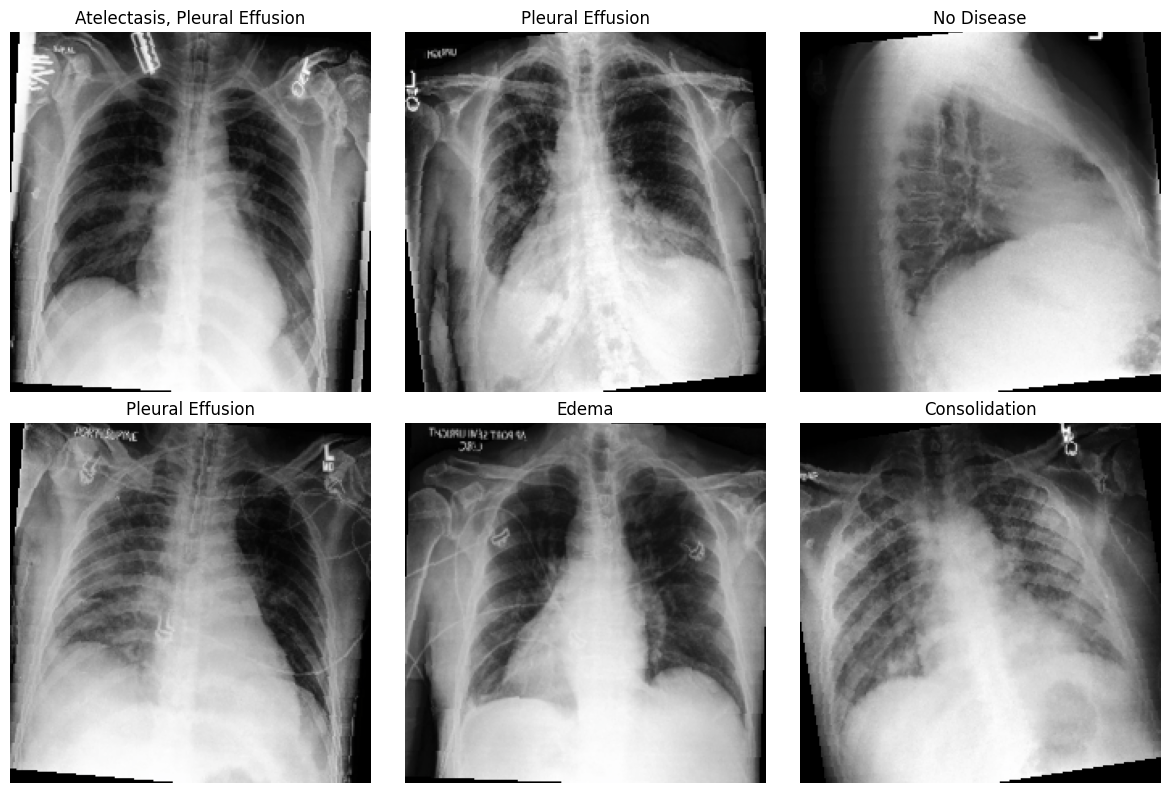

In [30]:
import matplotlib.pyplot as plt

disease_names = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

fig, axes = plt.subplots(2, 3, figsize=(12, 8))

for i, ax in enumerate(axes.flat[:6]):
    img = images[i].permute(1, 2, 0).numpy()

    # Undo ImageNet normalization
    img = img * [0.229, 0.224, 0.225] + [0.485, 0.456, 0.406]
    img = img.clip(0, 1)

    ax.imshow(img)

    positive = [disease_names[j] for j in range(5) if labels[i][j] == 1]

    ax.set_title(", ".join(positive) if positive else "No Disease")
    ax.axis("off")

plt.tight_layout()
plt.show()

# Target Diseases for Prediction

Instead of predicting all 14 CheXpert labels, this project focuses on five clinically important thoracic diseases. This simplifies the learning task while covering common abnormalities encountered in chest X-rays.

## 1. Atelectasis
- Partial or complete collapse of lung tissue.
- Reduces the amount of air reaching the lungs.
- Common after surgery or due to airway blockage.

## 2. Cardiomegaly
- Enlargement of the heart.
- Often associated with hypertension, heart failure, or other cardiac diseases.
- Can be an indicator of underlying cardiovascular problems.

## 3. Consolidation
- Lung tissue becomes filled with fluid instead of air.
- Frequently caused by pneumonia or severe lung infections.
- Appears as dense white regions on chest X-rays.

## 4. Edema
- Accumulation of fluid inside the lungs.
- Often linked to congestive heart failure.
- Can significantly affect breathing and oxygen exchange.

## 5. Pleural Effusion
- Collection of excess fluid between the lungs and chest wall.
- May occur due to infection, heart failure, or cancer.
- One of the most common abnormalities seen on chest radiographs.

---

## Prediction Task

This is a **multi-label image classification** problem.

A single chest X-ray may contain multiple diseases simultaneously, so the model predicts five independent probabilities, one for each disease.

In [31]:
# Import the pretrained DenseNet121 architecture
from torchvision import models

# Load DenseNet121 with ImageNet pretrained weights
# Pretrained weights help the model converge faster
model = models.densenet121(weights=models.DenseNet121_Weights.DEFAULT)

# Replace the original classifier
# DenseNet121 normally predicts 1000 ImageNet classes.
# We replace it with a new layer that predicts our 5 diseases.
num_features = model.classifier.in_features

model.classifier = torch.nn.Linear(
    in_features=num_features,
    out_features=5
)

Downloading: "https://download.pytorch.org/models/densenet121-a639ec97.pth" to /root/.cache/torch/hub/checkpoints/densenet121-a639ec97.pth


100%|██████████| 30.8M/30.8M [00:00<00:00, 178MB/s]


# DenseNet121 Model

We use **DenseNet121** as the baseline model for this project.

### Why DenseNet121?

- Pretrained on the ImageNet dataset.
- Uses dense connections that improve feature reuse and gradient flow.
- Has demonstrated strong performance on medical imaging tasks, including chest X-ray classification.
- Provides an excellent balance between accuracy and computational efficiency, making it suitable for Google Colab.

Since this is a **multi-label classification** problem, the final classification layer is replaced with **5 output neurons**, one for each target disease.

In [32]:
# ============================================================
# Step 1: Import Required Libraries
# ============================================================

import torch
import torch.nn as nn
from torchvision import models

# ============================================================
# Step 2: Check Whether GPU is Available
# ============================================================

# Use GPU if available; otherwise use CPU
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("Device:", device)

# ============================================================
# Step 3: Load the Pretrained DenseNet121 Model
# ============================================================

# Load DenseNet121 with pretrained ImageNet weights
model = models.densenet121(
    weights=models.DenseNet121_Weights.DEFAULT
)

# ============================================================
# Step 4: Replace the Final Classification Layer
# ============================================================

# Get the number of input features to the classifier
num_features = model.classifier.in_features

# Replace the original 1000-class classifier
# with a new classifier that predicts 5 diseases
model.classifier = nn.Linear(
    in_features=num_features,
    out_features=5
)

# ============================================================
# Step 5: Move Model to GPU
# ============================================================

model = model.to(device)

print(model.classifier)

Device: cuda
Linear(in_features=1024, out_features=5, bias=True)


# Loss Function and Optimizer

This project predicts multiple diseases independently for each chest X-ray.

Therefore:

- **Loss Function:** `BCEWithLogitsLoss`
  - Suitable for multi-label classification.
  - Combines the sigmoid activation and binary cross-entropy into one numerically stable operation.

- **Optimizer:** Adam
  - Adaptive learning rate optimization.
  - Commonly used for transfer learning because it converges efficiently.

The model will be evaluated primarily using **ROC-AUC** for each disease, along with the mean ROC-AUC across all five diseases.

In [33]:
# ============================================================
# Step 1: Define the Loss Function
# ============================================================

# BCEWithLogitsLoss is designed for multi-label classification.
# It applies the sigmoid activation internally and computes
# binary cross-entropy loss for each disease independently.
criterion = nn.BCEWithLogitsLoss()

# ============================================================
# Step 2: Define the Optimizer
# ============================================================

# Adam optimizer updates the model parameters during training.
optimizer = torch.optim.Adam(
    model.parameters(),
    lr=1e-4
)

print("Loss Function:", criterion)
print("Optimizer:", optimizer)

Loss Function: BCEWithLogitsLoss()
Optimizer: Adam (
Parameter Group 0
    amsgrad: False
    betas: (0.9, 0.999)
    capturable: False
    decoupled_weight_decay: False
    differentiable: False
    eps: 1e-08
    foreach: None
    fused: None
    lr: 0.0001
    maximize: False
    weight_decay: 0
)


# Computing Class Weights

The dataset is imbalanced because some diseases occur much more frequently than others.

To address this issue, we calculate a **positive class weight** (`pos_weight`) for each disease.

The weight is calculated as:

\[
\text{pos\_weight} = \frac{\text{Number of Negative Samples}}{\text{Number of Positive Samples}}
\]

This gives more importance to rare diseases during training and helps improve the model's ability to detect them.

The computed weights will be used inside `BCEWithLogitsLoss`.

In [34]:
# Import pandas for counting labels
import pandas as pd

# List of target diseases
TARGET_DISEASES = [
    "Atelectasis",
    "Cardiomegaly",
    "Consolidation",
    "Edema",
    "Pleural Effusion"
]

# Count positive samples (label = 1)
positive_counts = train_processed[TARGET_DISEASES].sum()

# Count negative samples (label = 0)
negative_counts = len(train_processed) - positive_counts

# Compute positive class weights
pos_weight = negative_counts / positive_counts

# Convert weights into a PyTorch tensor
pos_weight = torch.tensor(
    pos_weight.values,
    dtype=torch.float32
).to(device)

# Display the computed weights
print("Positive Samples")
print(positive_counts)

print("\nNegative Samples")
print(negative_counts)

print("\nPositive Class Weights")
print(pos_weight)

Positive Samples
Atelectasis         27147.0
Cardiomegaly        19421.0
Consolidation       11056.0
Edema               40526.0
Pleural Effusion    63773.0
dtype: float64

Negative Samples
Atelectasis         132182.0
Cardiomegaly        139908.0
Consolidation       148273.0
Edema               118803.0
Pleural Effusion     95556.0
dtype: float64

Positive Class Weights
tensor([ 4.8691,  7.2040, 13.4111,  2.9315,  1.4984], device='cuda:0')


In [35]:
# BCEWithLogitsLoss with class weights
criterion = nn.BCEWithLogitsLoss(
    pos_weight=pos_weight
)

print(criterion)

BCEWithLogitsLoss()


# Training Configuration

Before training the model, we define the hyperparameters used throughout the experiment.

### Hyperparameters

- **Epochs:** Number of complete passes through the training dataset.
- **Batch Size:** Number of images processed before updating the model weights.
- **Learning Rate:** Controls how much the model updates after each batch.

These values provide a strong starting point for transfer learning and can be tuned later if needed.

In [36]:
# Number of complete passes through the training dataset
NUM_EPOCHS = 10

# Learning rate for the optimizer
LEARNING_RATE = 1e-4 #means 0.0001

# Batch size (already used while creating DataLoaders)
BATCH_SIZE = 32

print(f"Epochs: {NUM_EPOCHS}")
print(f"Learning Rate: {LEARNING_RATE}")
print(f"Batch Size: {BATCH_SIZE}")

Epochs: 10
Learning Rate: 0.0001
Batch Size: 32


# Training Function

The training function performs one complete pass through the training dataset.

For every batch it:

1. Loads images and labels.
2. Moves them to the GPU.
3. Performs a forward pass.
4. Computes the loss.
5. Calculates gradients using backpropagation.
6. Updates the model parameters.
7. Returns the average training loss for the epoch.

In [37]:
def train_one_epoch(model, dataloader, criterion, optimizer, device):
    """
    Trains the model for one epoch.

    Parameters:
        model: Neural network model
        dataloader: Training DataLoader
        criterion: Loss function
        optimizer: Optimizer
        device: CPU or GPU

    Returns:
        Average training loss for one epoch
    """

    # Set the model to training mode
    model.train()

    running_loss = 0.0

    # Loop through every batch
    for images, labels in dataloader:

        # Move data to the selected device
        images = images.to(device)
        labels = labels.to(device)

        # Clear gradients from the previous batch
        optimizer.zero_grad()

        # Forward pass
        outputs = model(images)

        # Compute loss
        loss = criterion(outputs, labels)

        # Backpropagation
        loss.backward()

        # Update model parameters
        optimizer.step()

        # Add batch loss
        running_loss += loss.item()

    # Calculate average loss
    epoch_loss = running_loss / len(dataloader)

    return epoch_loss

# Validation Function

The validation function evaluates the model on unseen validation data.

Unlike training:

- Model weights are **not updated**.
- Gradient computation is disabled to improve efficiency.
- The function returns:
  - Average validation loss
  - Predicted probabilities
  - Ground truth labels

The predicted probabilities and true labels will later be used to calculate the ROC-AUC score for each disease.

In [38]:
def validate_one_epoch(model, dataloader, criterion, device):
    """
    Evaluates the model on the validation dataset.

    Parameters:
        model: Neural network model
        dataloader: Validation DataLoader
        criterion: Loss function
        device: CPU or GPU

    Returns:
        Average validation loss
        Predicted probabilities
        Ground truth labels
    """

    # Set the model to evaluation mode
    model.eval()

    running_loss = 0.0

    all_predictions = []
    all_labels = []

    # Disable gradient calculations
    with torch.no_grad():

        # Loop through every validation batch
        for images, labels in dataloader:

            # Move data to the selected device
            images = images.to(device)
            labels = labels.to(device)

            # Forward pass
            outputs = model(images)

            # Compute validation loss
            loss = criterion(outputs, labels)

            running_loss += loss.item()

            # Convert logits into probabilities
            probabilities = torch.sigmoid(outputs)

            # Store predictions and labels
            all_predictions.append(probabilities.cpu())
            all_labels.append(labels.cpu())

    # Average validation loss
    validation_loss = running_loss / len(dataloader)

    # Combine all batches
    all_predictions = torch.cat(all_predictions)
    all_labels = torch.cat(all_labels)

    return validation_loss, all_predictions, all_labels

# Why Use Sigmoid?

DenseNet121 produces **logits**, which are raw output values.

Applying the **sigmoid function** converts each logit into a probability between 0 and 1.

Since this is a **multi-label classification** problem, each disease is predicted independently.

For example:

| Disease | Probability |
|----------|------------:|
| Atelectasis | 0.81 |
| Cardiomegaly | 0.12 |
| Consolidation | 0.67 |
| Edema | 0.09 |
| Pleural Effusion | 0.94 |

These probabilities are used to compute the ROC-AUC score for each disease.

# ROC-AUC Evaluation

Medical image datasets are often highly imbalanced, making **accuracy** a misleading metric.

Instead, we use the **Receiver Operating Characteristic - Area Under the Curve (ROC-AUC)**.

ROC-AUC measures how well the model distinguishes between positive and negative cases across all possible classification thresholds.

For this project, we compute:

- ROC-AUC for each of the five diseases.
- Mean ROC-AUC, which is the average performance across all target diseases.

The Mean ROC-AUC will be the primary metric used to compare different model architectures.

In [39]:
# Import NumPy for numerical operations
import numpy as np

# Import ROC-AUC metric
from sklearn.metrics import roc_auc_score

In [40]:
def calculate_auc(labels, predictions, disease_names):
    """
    Calculates the ROC-AUC score for each disease and the mean ROC-AUC.

    Parameters:
        labels: Ground truth labels
        predictions: Model predicted probabilities
        disease_names: List of disease names

    Returns:
        Dictionary containing ROC-AUC for each disease
        Mean ROC-AUC
    """

    auc_scores = {}

    # Calculate ROC-AUC for each disease independently
    for i, disease in enumerate(disease_names):

        auc = roc_auc_score(
            labels[:, i],
            predictions[:, i]
        )

        auc_scores[disease] = auc

    # Compute the average ROC-AUC
    mean_auc = np.mean(list(auc_scores.values()))

    return auc_scores, mean_auc

In [43]:
!nvidia-smi

Fri Jul 31 10:08:51 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  Tesla T4                       Off |   00000000:00:04.0 Off |                    0 |
| N/A   75C    P0             41W /   70W |    4939MiB /  15360MiB |      0%      Default |
|                                         |                        |                  N/A |
+-----------------------------------------+-----

In [41]:
# Test AUROC calculation after one validation pass

validation_loss, predictions, labels = validate_one_epoch(
    model,
    valid_loader,
    criterion,
    device
)

auc_scores, mean_auc = calculate_auc(
    labels.numpy(),
    predictions.numpy(),
    TARGET_DISEASES
)

print(f"Validation Loss: {validation_loss:.4f}\n")

for disease, auc in auc_scores.items():
    print(f"{disease:<20}: {auc:.4f}")

print(f"\nMean ROC-AUC: {mean_auc:.4f}")

Validation Loss: 1.4459

Atelectasis         : 0.3472
Cardiomegaly        : 0.4689
Consolidation       : 0.4517
Edema               : 0.4985
Pleural Effusion    : 0.5445

Mean ROC-AUC: 0.4622


# Training Loop

The training loop controls the complete learning process.

For each epoch, the following steps are performed:

1. Train the model on the training dataset.
2. Evaluate the model on the validation dataset.
3. Calculate the ROC-AUC score for each disease.
4. Compute the Mean ROC-AUC.
5. Save the model if it achieves the best Mean ROC-AUC.

This ensures that the best-performing model is preserved during training.

In [42]:
# Store the best Mean ROC-AUC achieved so far
best_auc = 0.0

# Dictionary to store training history
history = {
    "train_loss": [],
    "valid_loss": [],
    "mean_auc": []
}

# Start training
for epoch in range(NUM_EPOCHS):

    print(f"\nEpoch {epoch + 1}/{NUM_EPOCHS}")
    print("=" * 50)

    # Train for one epoch
    train_loss = train_one_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    # Validate the model
    valid_loss, predictions, labels = validate_one_epoch(
        model,
        valid_loader,
        criterion,
        device
    )

    # Calculate ROC-AUC scores
    auc_scores, mean_auc = calculate_auc(
        labels.numpy(),
        predictions.numpy(),
        TARGET_DISEASES
    )

    # Save metrics
    history["train_loss"].append(train_loss)
    history["valid_loss"].append(valid_loss)
    history["mean_auc"].append(mean_auc)

    # Print epoch summary
    print(f"Training Loss   : {train_loss:.4f}")
    print(f"Validation Loss : {valid_loss:.4f}")
    print(f"Mean ROC-AUC    : {mean_auc:.4f}")

    print("\nDisease-wise ROC-AUC")

    for disease, auc in auc_scores.items():
        print(f"{disease:<20}: {auc:.4f}")

    # Save the best model
    if mean_auc > best_auc:

        best_auc = mean_auc

        torch.save(
            model.state_dict(),
            "best_densenet121.pth"
        )

        print("\n✅ Best model saved!")

print("\nTraining completed.")
print(f"Best Mean ROC-AUC: {best_auc:.4f}")


Epoch 1/10
Training Loss   : 0.8758
Validation Loss : 1.0390
Mean ROC-AUC    : 0.8694

Disease-wise ROC-AUC
Atelectasis         : 0.7683
Cardiomegaly        : 0.8485
Consolidation       : 0.8984
Edema               : 0.9122
Pleural Effusion    : 0.9197

✅ Best model saved!

Epoch 2/10
Training Loss   : 0.8331
Validation Loss : 1.0355
Mean ROC-AUC    : 0.8674

Disease-wise ROC-AUC
Atelectasis         : 0.7942
Cardiomegaly        : 0.8580
Consolidation       : 0.8782
Edema               : 0.8829
Pleural Effusion    : 0.9239

Epoch 3/10
Training Loss   : 0.8160
Validation Loss : 1.0534
Mean ROC-AUC    : 0.8740

Disease-wise ROC-AUC
Atelectasis         : 0.7915
Cardiomegaly        : 0.8283
Consolidation       : 0.8972
Edema               : 0.9205
Pleural Effusion    : 0.9326

✅ Best model saved!

Epoch 4/10
Training Loss   : 0.8023
Validation Loss : 1.1149
Mean ROC-AUC    : 0.8639

Disease-wise ROC-AUC
Atelectasis         : 0.8060
Cardiomegaly        : 0.7869
Consolidation       : 0.8850


In [44]:
import os
import shutil

save_folder = "/content/drive/MyDrive/ChestXRay_Project"
os.makedirs(save_folder, exist_ok=True)

shutil.copy(
    "best_densenet121.pth",
    os.path.join(save_folder, "best_densenet121.pth")
)

print("Model successfully saved to Google Drive.")

Model successfully saved to Google Drive.


In [45]:
import os
import shutil

save_folder = "/content/drive/MyDrive/ChestXRay_Project"
os.makedirs(save_folder, exist_ok=True)

shutil.copy(
    "best_densenet121.pth",
    os.path.join(save_folder, "best_densenet121.pth")
)

print("Model successfully saved to Google Drive.")

Model successfully saved to Google Drive.
